In [12]:
import pandas as pd
import numpy as np

# Load Pima Indians Diabetes dataset from public repository
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_df = pd.read_csv(url, header=None, names=columns)



# Count invalid zero values in features where a zero is physiologically impossible
zero_counts = (pima_df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()


In [13]:
from sklearn.impute import SimpleImputer

# Replace invalid zero values with NaN
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
pima_df[cols_to_impute] = pima_df[cols_to_impute].replace(0, np.nan)


# Apply median imputation to replace NaN values
imputer = SimpleImputer(strategy='median')
pima_df[cols_to_impute] = imputer.fit_transform(pima_df[cols_to_impute])



In [14]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

features = columns[:-1]
X = pima_df[features]

# Apply MinMaxScaler (Normalization)
min_max_scaler = MinMaxScaler()
X_normalized = min_max_scaler.fit_transform(X)

# Apply StandardScaler (Standardization)
standard_scaler = StandardScaler()
X_standardized = standard_scaler.fit_transform(X)


In [15]:
from sklearn.preprocessing import PowerTransformer

# Evaluate raw skewness of the Insulin column
original_skew = pima_df['Insulin'].skew()

# Apply Yeo-Johnson transformation to stabilize variance
power_transformer = PowerTransformer(method='yeo-johnson')
insulin_transformed = power_transformer.fit_transform(pima_df[['Insulin']])

# Check the new skewness coefficient
transformed_skew = pd.Series(insulin_transformed.flatten()).skew()


In [16]:
  # Create preprocessed DataFrame combining standardized features and outcomes
  processed_pima_df = pd.DataFrame(data=X_standardized, columns=features)
  processed_pima_df['Outcome'] = pima_df['Outcome']

  # Export to system directory
  processed_pima_df.to_csv("processed_pima_diabetes.csv", index=False)

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M (Mine) -> 1, R (Rock) -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]

# Scale features
scaler = StandardScaler()
X_sonar_scaled = scaler.fit_transform(X_sonar)



In [18]:
from sklearn.decomposition import PCA

# Apply PCA to preserve 90% of total variance
pca_90 = PCA(n_components=0.90, random_state=42)
X_pca_90 = pca_90.fit_transform(X_sonar_scaled)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Evaluate performance on all 60 scaled raw features
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_sonar_scaled, sonar_df['Class_numeric'], test_size=0.3, random_state=42)
lr_raw = LogisticRegression()
lr_raw.fit(X_train_raw, y_train)
acc_raw = accuracy_score(y_test, lr_raw.predict(X_test_raw))

# Evaluate performance on the reduced PCA components
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca_90, sonar_df['Class_numeric'], test_size=0.3, random_state=42)
lr_pca = LogisticRegression()
lr_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, lr_pca.predict(X_test_pca))




In [22]:
from sklearn.feature_selection import SelectKBest, f_classif
print("Roll Number:24EU01097")

# Rank and select the top 4 features using SelectKBest (ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X_standardized, pima_df['Outcome'])

# Build a summary DataFrame of feature scores
anova_scores = pd.DataFrame({'Feature': features, 'F-Score': selector.scores_}).sort_values(by='F-Score', ascending=False)
print("ANOVA F-Test Scores:\n", anova_scores)


Roll Number:24EU01097
ANOVA F-Test Scores:
                     Feature     F-Score
1                   Glucose  245.667855
5                       BMI   82.629271
7                       Age   46.140611
0               Pregnancies   39.670227
3             SkinThickness   37.078538
4                   Insulin   33.190796
6  DiabetesPedigreeFunction   23.871300
2             BloodPressure   21.631580


In [23]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
print("Roll Number:24EU01097")

# Run RFE using Logistic Regression to select the top 4 features
estimator = LogisticRegression()
rfe = RFE(estimator=estimator, n_features_to_select=4)
rfe.fit(X_standardized, pima_df['Outcome'])

# Build selection ranking summary
rfe_support = pd.DataFrame({'Feature': features, 'Selected': rfe.support_, 'Ranking': rfe.ranking_}).sort_values(by='Ranking')
print("RFE Selected Features:\n", rfe_support)


Roll Number:24EU01097
RFE Selected Features:
                     Feature  Selected  Ranking
0               Pregnancies      True        1
1                   Glucose      True        1
5                       BMI      True        1
6  DiabetesPedigreeFunction      True        1
7                       Age     False        2
2             BloodPressure     False        3
4                   Insulin     False        4
3             SkinThickness     False        5


In [24]:
from sklearn.linear_model import LogisticRegression
print("Roll Number:24EU01097")

# Run Logistic Regression with Lasso (L1) regularization
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
lasso.fit(X_standardized, pima_df['Outcome'])

# Display feature coefficients (zero-coefficients indicate dropped features)
lasso_coefs = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)
print("Lasso Regularization Coefficients:\n", lasso_coefs)


Roll Number:24EU01097
Lasso Regularization Coefficients:
                     Feature  Coefficient
1                   Glucose     1.106412
5                       BMI     0.611338
0               Pregnancies     0.399515
6  DiabetesPedigreeFunction     0.269034
7                       Age     0.134767
2             BloodPressure    -0.073190
4                   Insulin    -0.067230
3             SkinThickness     0.019400


Roll Number: 24EU01097
Random Forest Feature Importances:
                     Feature  Importance
1                   Glucose    0.263715
5                       BMI    0.167470
7                       Age    0.127208
6  DiabetesPedigreeFunction    0.124075
4                   Insulin    0.084843
2             BloodPressure    0.082722
0               Pregnancies    0.079268
3             SkinThickness    0.070699


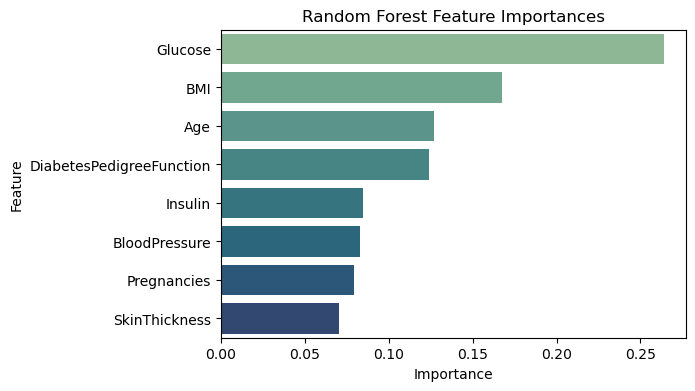

In [25]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
print("Roll Number: 24EU01097")
warnings.filterwarnings("ignore")
# Train Random Forest to compute Gini feature importances
rf = RandomForestClassifier(random_state=42)
rf.fit(X, pima_df['Outcome']) # Random Forest is scale invariant; raw values are suitable

# Plot feature importances
importances = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
print("Random Forest Feature Importances:\n", importances)

plt.figure(figsize=(6, 4))
sns.barplot(data=importances, x='Importance', y='Feature', palette='crest')
plt.title("Random Forest Feature Importances")
plt.show()


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
print("Roll Number: 24EU01097")

# Split dataset into training and test sets
X_train, X_test, y_train_p, y_test_p = train_test_split(X, pima_df['Outcome'], test_size=0.3, random_state=42)

# Model 1: Train on all 8 features
rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(X_train, y_train_p)
preds_full = rf_full.predict(X_test)

# Model 2: Train on only the top 4 features identified by Random Forest
top_4_cols = importances.head(4)['Feature'].tolist()
X_train_sub = X_train[top_4_cols]
X_test_sub = X_test[top_4_cols]

rf_sub = RandomForestClassifier(random_state=42)
rf_sub.fit(X_train_sub, y_train_p)
preds_sub = rf_sub.predict(X_test_sub)

print("--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---")
print(classification_report(y_test_p, preds_full))

print("\n--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---")
print(classification_report(y_test_p, preds_sub))


Roll Number: 24EU01097
--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.63      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.72      0.73      0.73       231
weighted avg       0.75      0.75      0.75       231


--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       151
           1       0.60      0.68      0.64        80

    accuracy                           0.73       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.73      0.73       231

